# HD-MEA LFP Phase Waves

Minimal notebook for chunked traveling phase-wave estimation from MaxTwo HD-MEA LFP. The full recording is never loaded into memory; diagnostic cells use short excerpts only.


In [375]:
%matplotlib inline
import sys
import importlib
import json
from pathlib import Path

repo_root = Path.cwd().resolve()
if not (repo_root / "phase_waves.py").exists():
    repo_root = repo_root.parent.resolve()
if not (repo_root / "phase_waves.py").exists():
    raise FileNotFoundError("Run this notebook from the repo root or from Notebooks/ so phase_waves.py can be found.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import welch

from ephax.data_io import load_spikes
from ephax.metrics.burst import (
    assign_max_population_ifr_burst_anchors,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
)
from ephax.plotting.burst import (
    draw_high_activity_burst_windows,
    draw_population_ifr_summary,
    population_ifr_summary_axes_factory,
)
from ephax.prep import Recording

import phase_waves
phase_waves = importlib.reload(phase_waves)

from phase_waves import (
    bandpass_downsample,
    demodulated_window_phasor,
    estimate_omega,
    extract_phasors,
    fit_k_phasor_plane,
    fit_k_radial_phasor,
    inspect_file,
    load_chunk,
    make_k_grid,
    make_radial_grid,
    process_file,
)


## Configure


In [376]:
# LFP source switch: "stim_removal_null_lfp" for the new six-well file, or "raw_h5_control_2" for the previous LFP file.
LFP_SOURCE = "stim_removal_null_lfp"
WELL = 0
DIV = 12

RAW_H5_CONTROL_2_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/ephaptic_stimulation_caspfiguration_control_2.raw.h5")
STIM_REMOVAL_NULL_LFP_ROOT = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull")
STIM_REMOVAL_NULL_LFP_FILE = STIM_REMOVAL_NULL_LFP_ROOT / f"DIV {int(DIV)}" / "data.raw.h5"
PREVIOUS_SPIKE_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/Stimulation/2407/control_2.raw.h5")


def dataset_for_well(well):
    return f"data{int(well):04d}"


def load_data_store_spikes(file_path, dataset, *, min_amp=0.0):
    """Load MaxTwo data_store spikes for the same well/data000N used by the LFP analysis."""
    raw_path, rec_group_path = phase_waves._resolve_dataset_paths(dataset, file_path)
    with h5py.File(file_path, "r") as h5:
        rec_group = h5[rec_group_path]
        settings = rec_group["settings"]
        mapping_obj = settings["mapping"]
        if getattr(mapping_obj, "dtype", None) is not None and mapping_obj.dtype.fields is not None:
            mapping_arr = mapping_obj[:]
            layout = {name: np.asarray(mapping_arr[name]) for name in ("channel", "electrode", "x", "y")}
        else:
            layout = {name: np.asarray(mapping_obj[name])[:] for name in ("channel", "electrode", "x", "y")}
        sf = float(settings["sampling"][0])
        spikes_arr = rec_group["spikes"][:]
        frame_nos = h5[raw_path].parent.get("frame_nos")
        first_frame = int(frame_nos[0]) if frame_nos is not None and frame_nos.shape[0] else int(np.nanmin(spikes_arr["frameno"])) if spikes_arr.size else 0

        spikes_data = {
            "time": (np.asarray(spikes_arr["frameno"], dtype=float) - first_frame) / sf,
            "channel": np.asarray(spikes_arr["channel"]),
            "amplitude": np.asarray(spikes_arr["amplitude"]),
        }
        channel_to_electrode = {int(ch): int(el) for ch, el in zip(layout["channel"], layout["electrode"])}
        spikes_data["electrode"] = np.asarray([channel_to_electrode.get(int(ch), -1) for ch in spikes_data["channel"]])
        keep = (spikes_data["electrode"] >= 0) & (spikes_data["time"] >= 0) & (np.abs(spikes_data["amplitude"]) >= float(min_amp))
        spikes_data = {key: np.asarray(value)[keep] for key, value in spikes_data.items()}

        if "events" in rec_group:
            events = rec_group["events"][:]
            if events.size:
                event_data = {name: np.asarray(events[name]) for name in events.dtype.names}
                if "frameno" in event_data:
                    event_data["time"] = (np.asarray(event_data["frameno"], dtype=float) - first_frame) / sf
            else:
                event_data = {"time": np.array([])}
        else:
            event_data = {"time": np.array([])}

    return spikes_data, event_data, layout, sf, None


if LFP_SOURCE == "stim_removal_null_lfp":
    FILE = STIM_REMOVAL_NULL_LFP_FILE
    DATASET = dataset_for_well(WELL)
    SPIKE_SOURCE = "lfp_data_store"
    SPIKE_FILE = FILE
elif LFP_SOURCE == "raw_h5_control_2":
    FILE = RAW_H5_CONTROL_2_FILE
    DATASET = dataset_for_well(WELL)
    SPIKE_SOURCE = "processed_h5"
    SPIKE_FILE = PREVIOUS_SPIKE_FILE
else:
    raise ValueError("LFP_SOURCE must be 'stim_removal_null_lfp' or 'raw_h5_control_2'.")

SPIKE_WELL = int(WELL)

BAND_LOW = 42.0
BAND_HIGH = 48.0
FS_DS = 500.0
SPECTRO_LOW = 1.0
SPECTRO_HIGH = 180.0
CHUNK_S = 30.0
OVERLAP_S = 1.0
WIN_MS = 100.0
HOP_MS = 50.0
LAMBDA_MIN = 0.5
LAMBDA_MAX = 5.0

FIT_RADIAL = True
RADIAL_CENTER_GRID_N = 15
RADIAL_CENTER_MARGIN_MM = 0.0
RADIAL_DELTA_R_MIN = 0.05

WAVE_OUTPUT_DIR = repo_root / "outputs" / "lfp_waves"
WAVE_FORCE_RECOMPUTE = False

SPIKE_MIN_AMP = 0.0
N_ACTIVE_ELECTRODES = 1000
IFR_GRID_HZ = 50.0
IFR_SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 1
HIGHRES_BIN_MS = 20.0
HIGHRES_SMOOTH_SIGMA_MS = 20.0
PARTICIPATION_AGGREGATION_MS = 50.0
BURST_MIN_PARTICIPATION = 0.05
BURST_MIN_DURATION_MS = 30.0
WAVE_INTERVAL_MODE = "high_activity"  # "all", "high_activity", or "burst"
RUN_START_S = 0.0
RUN_STOP_S = None  # set to None for full available recording
WAVE_INTERVAL_SCOPE = "all_detected"  # "run_range" or "all_detected" when mode is high_activity/burst
WAVE_MAX_INTERVALS = None  # e.g. 25 for a quick first pass over selected intervals
INTERVAL_PAD_S = 0.0
LFP_PREVIEW_INTERVALS = 3
LFP_PREVIEW_MAX_S_PER_INTERVAL = 2.0

wave_output_label = (
    f"{LFP_SOURCE}_well{int(WELL)}_DIV{int(DIV)}_"
    f"{DATASET}_{WAVE_INTERVAL_MODE}_"
    f"{BAND_LOW:g}-{BAND_HIGH:g}Hz_fs{FS_DS:g}_"
    f"win{WIN_MS:g}_hop{HOP_MS:g}_"
    f"lambda{LAMBDA_MIN:g}-{LAMBDA_MAX:g}_"
    f"radial{int(FIT_RADIAL)}"
)
OUT_PATH = WAVE_OUTPUT_DIR / f"phase_waves_{wave_output_label}.h5"

print(f"LFP source: {LFP_SOURCE}; file={FILE}")
print(f"LFP well {WELL} -> dataset {DATASET}; spike source={SPIKE_SOURCE}")


LFP source: stim_removal_null_lfp; file=/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull/DIV 12/data.raw.h5
LFP well 0 -> dataset data0000; spike source=lfp_data_store


## Inspect Metadata


In [377]:
info = inspect_file(FILE, DATASET)
info


{'raw_path': '/data_store/data0000/groups/routed/raw',
 'recording_group': '/data_store/data0000',
 'raw_shape': (1020, 6000200),
 'n_mapped_channels': 1020,
 'fs_raw': 10000.0,
 'lsb': 6.29425039733178e-06,
 'x_um_min': 17.5,
 'x_um_max': 3797.5,
 'y_um_min': 17.5,
 'y_um_max': 2082.5}

## Spike-Derived High-Activity And Burst Windows


In [378]:
if SPIKE_SOURCE == "lfp_data_store":
    spikes_data, spike_events, spike_layout, spike_sf, stimulus_electrode = load_data_store_spikes(
        SPIKE_FILE,
        DATASET,
        min_amp=SPIKE_MIN_AMP,
    )
elif SPIKE_SOURCE == "processed_h5":
    spikes_data, spike_events, spike_layout, spike_sf, stimulus_electrode = load_spikes(
        SPIKE_FILE,
        SPIKE_WELL,
        min_amp=SPIKE_MIN_AMP,
    )
else:
    raise ValueError(f"Unsupported SPIKE_SOURCE={SPIKE_SOURCE!r}")

recording_stop_s = info["raw_shape"][1] / info["fs_raw"]
spike_stop_s = float(np.nanmax(spikes_data["time"])) if len(spikes_data["time"]) else recording_stop_s
analysis_stop_s = min(recording_stop_s, spike_stop_s)
spike_recording = Recording(
    spikes=spikes_data,
    layout=spike_layout,
    start_time=0.0,
    end_time=analysis_stop_s,
    sf=float(spike_sf),
)
selected_refs = spike_recording.refs_top(start=0, stop=N_ACTIVE_ELECTRODES)
print(f"Loaded {SPIKE_SOURCE} well {SPIKE_WELL}: {len(spikes_data['time']):,} spikes, {len(spike_layout['electrode']):,} mapped electrodes")
print(f"Selected {len(selected_refs):,} active electrodes for IFR/burst detection over 0-{analysis_stop_s:.2f} s")


Loaded lfp_data_store well 0: 479,452 spikes, 1,020 mapped electrodes
Selected 1,000 active electrodes for IFR/burst detection over 0-599.82 s


In [379]:
population = build_population_ifr(
    spike_recording,
    selected_refs,
    grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=IFR_SMOOTH_SIGMA_SEC,
)
high_activity_epochs, high_activity_info = detect_high_activity_epochs(
    population.time_grid,
    population.mean_ifr_smooth,
    mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
)
highres = build_highres_traces(
    spike_recording,
    selected_refs,
    bin_ms=HIGHRES_BIN_MS,
    smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
)
network_activity = build_participation_activity_state(
    highres,
    aggregation_ms=PARTICIPATION_AGGREGATION_MS,
)
burst_epochs = detect_participation_burst_epochs(
    network_activity,
    high_activity_epochs,
    min_participation_fraction=BURST_MIN_PARTICIPATION,
    min_duration_ms=BURST_MIN_DURATION_MS,
)
burst_epochs = assign_max_population_ifr_burst_anchors(highres, burst_epochs)
print(f"High-activity epochs: {len(high_activity_epochs)}")
print(f"Burst epochs: {len(burst_epochs)}")
print(f"High-activity threshold: {high_activity_info['threshold_hz']:.3f} Hz")
display(high_activity_epochs.head(10).round(3))
display(burst_epochs.head(10).round(3))


High-activity epochs: 28
Burst epochs: 47
High-activity threshold: 0.519 Hz


,event_idx,start_idx,end_idx,start_time_s,end_time_s,peak_idx,peak_time_s,peak_mean_ifr_hz,duration_ms,threshold_hz,baseline_hz
0,0,784,1075,15.68,21.52,908,18.16,5.912,5840.0,0.519,0.316
1,1,1993,2249,39.86,45.00,2018,40.36,5.409,5140.0,0.519,0.316
2,2,3069,3318,61.38,66.38,3181,63.62,6.003,5000.0,0.519,0.316
3,3,4064,4360,81.28,87.22,4126,82.52,5.476,5940.0,0.519,0.316
4,4,5204,5454,104.08,109.10,5314,106.28,6.221,5020.0,0.519,0.316
5,5,6258,6502,125.16,130.06,6375,127.50,6.110,4900.0,0.519,0.316
6,6,7558,7817,151.16,156.36,7666,153.32,6.234,5200.0,0.519,0.316
7,7,8764,9033,175.28,180.68,8791,175.82,5.453,5400.0,0.519,0.316
8,8,9702,9965,194.04,199.32,9729,194.58,5.409,5280.0,0.519,0.316
9,9,10720,10962,214.40,219.26,10835,216.70,6.059,4860.0,0.519,0.316


,event_idx,high_activity_event_idx,start_idx,end_idx,start_time_s,end_time_s,coarse_peak_idx,coarse_peak_time_s,coarse_peak_hz,anchor_time_s,...,peak_participation_fraction,peak_active_electrodes,participating_electrodes,total_spikes,duration_ms,min_active_electrodes,subpeak_count,participation_anchor_time_s,anchor_method,anchor_population_rate_hz
0,0,0,265,349,15.90,21.00,805,16.11,14.375,16.11,...,0.487,487,990,16285,5100.0,50,1,16.11,max_highres_population_ifr,14.375
1,1,1,668,735,40.08,44.16,2014,40.29,14.239,40.29,...,0.488,488,980,10391,4080.0,50,1,40.29,max_highres_population_ifr,14.239
2,2,2,1027,1094,61.62,65.70,3089,61.79,13.561,61.79,...,0.493,493,984,12121,4080.0,50,1,61.83,max_highres_population_ifr,13.561
3,3,2,1097,1097,65.82,65.88,3293,65.87,0.872,65.87,...,0.051,51,51,51,60.0,50,1,65.85,max_highres_population_ifr,0.872
4,4,3,1371,1440,82.26,86.46,4123,82.47,14.929,82.47,...,0.493,493,988,10960,4200.0,50,1,82.47,max_highres_population_ifr,14.929
5,5,4,1738,1806,104.28,108.42,5226,104.53,16.162,104.53,...,0.588,588,988,12604,4140.0,50,1,104.55,max_highres_population_ifr,16.162
6,6,4,1809,1810,108.54,108.66,5427,108.55,0.808,108.55,...,0.051,51,96,101,120.0,50,1,108.63,max_highres_population_ifr,0.808
7,7,5,2090,2154,125.40,129.30,6282,125.65,11.713,125.65,...,0.394,394,981,12185,3900.0,50,1,127.53,max_highres_population_ifr,11.713
8,8,5,2160,2160,129.60,129.66,6482,129.65,0.928,129.65,...,0.054,54,54,54,60.0,50,1,129.63,max_highres_population_ifr,0.928
9,9,6,2524,2593,151.44,155.64,7580,151.61,15.676,151.61,...,0.489,489,987,13211,4200.0,50,1,151.59,max_highres_population_ifr,15.676


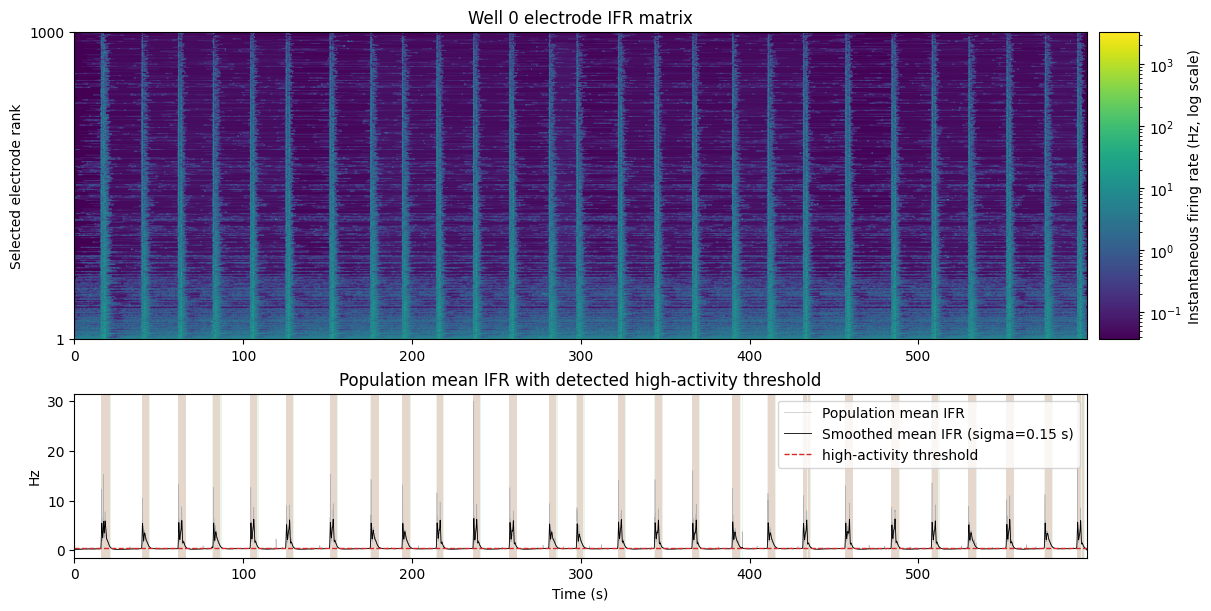

In [380]:
fig = plt.figure(figsize=(12, 6), constrained_layout=True)
axes = population_ifr_summary_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_population_ifr_summary(
    population,
    axes,
    heatmap_title=f"Well {SPIKE_WELL} electrode IFR matrix",
    mean_title="Population mean IFR with detected high-activity threshold",
    smooth_sigma_sec=IFR_SMOOTH_SIGMA_SEC,
)
axes[1].axhline(high_activity_info["threshold_hz"], color="tab:red", ls="--", lw=1.0, label="high-activity threshold")
for row in high_activity_epochs.itertuples(index=False):
    axes[1].axvspan(row.start_time_s, row.end_time_s, color="tab:green", alpha=0.10, lw=0)
for row in burst_epochs.itertuples(index=False):
    axes[1].axvspan(row.start_time_s, row.end_time_s, color="tab:red", alpha=0.14, lw=0)
axes[1].legend(loc="upper right")


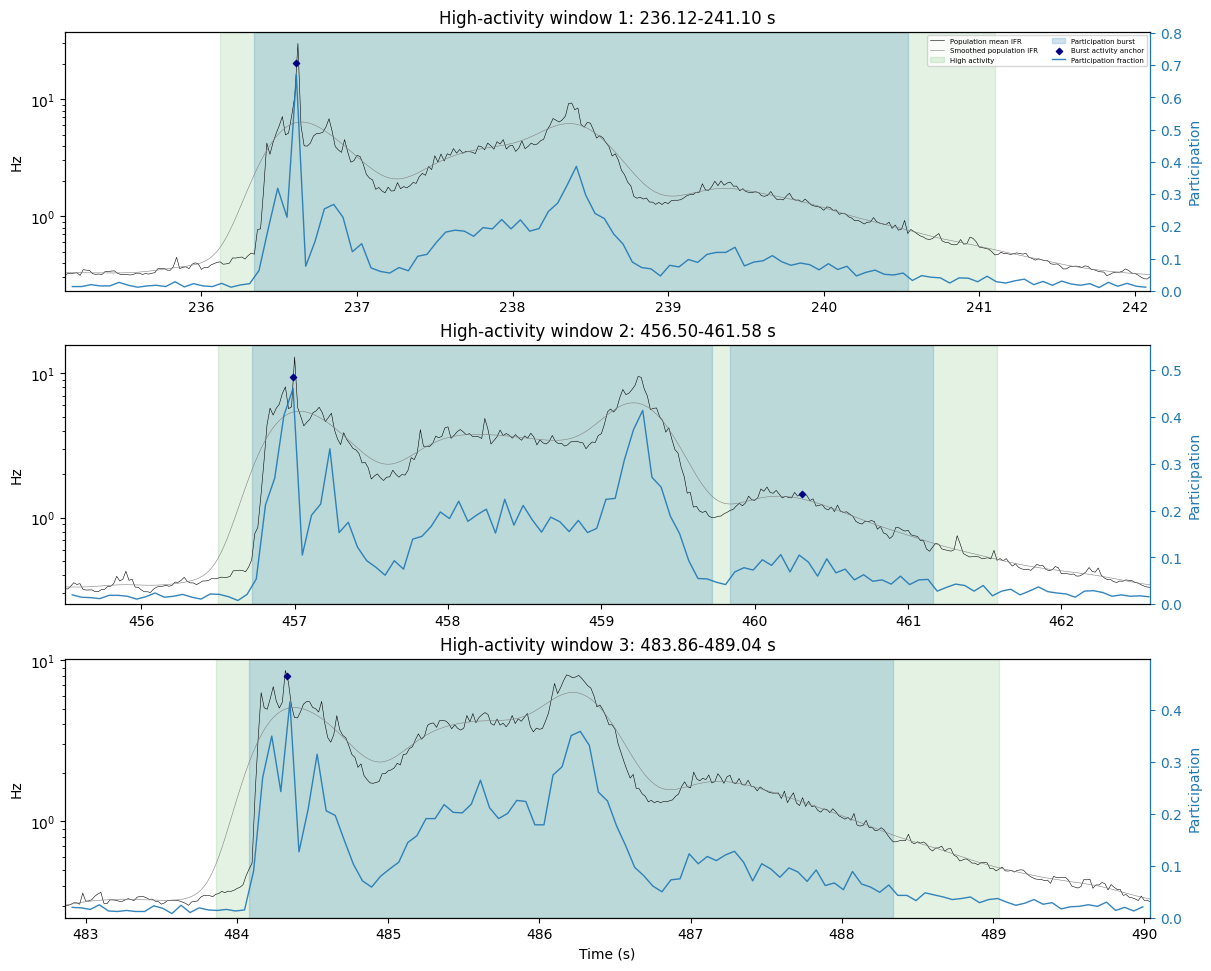

In [381]:
if high_activity_epochs.empty:
    print("No high-activity windows detected with the current settings.")
else:
    n_panels = min(3, len(high_activity_epochs))
    fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3.2 * n_panels), squeeze=False, constrained_layout=True)
    draw_high_activity_burst_windows(
        {
            "time_grid": population.time_grid,
            "mean_ifr": population.mean_ifr,
            "mean_ifr_smooth": population.mean_ifr_smooth,
            "network_activity": network_activity,
            "high_activity_epochs": high_activity_epochs,
            "burst_epochs": burst_epochs,
            "high_activity_threshold_hz": high_activity_info["threshold_hz"],
            "participation_threshold": BURST_MIN_PARTICIPATION,
        },
        axes.reshape(-1),
        n_windows=n_panels,
        pad_s=1.0,
        window_order="peak_ifr",
    )


In [382]:
def intervals_from_epochs(epochs, *, pad_s=0.0, start_s=0.0, stop_s=None):
    if epochs is None or len(epochs) == 0:
        return []
    stop_s = analysis_stop_s if stop_s is None else float(stop_s)
    intervals = []
    for row in epochs[["start_time_s", "end_time_s"]].itertuples(index=False):
        a = max(float(start_s), float(row.start_time_s) - float(pad_s))
        b = min(float(stop_s), float(row.end_time_s) + float(pad_s))
        if b > a:
            intervals.append((a, b))
    return intervals

def interval_summary(intervals):
    frame = pd.DataFrame(intervals, columns=["start_time_s", "end_time_s"])
    if frame.empty:
        frame["duration_s"] = []
        return frame
    frame["duration_s"] = frame["end_time_s"] - frame["start_time_s"]
    return frame

high_activity_intervals = intervals_from_epochs(high_activity_epochs, pad_s=INTERVAL_PAD_S)
burst_intervals = intervals_from_epochs(burst_epochs, pad_s=INTERVAL_PAD_S)
all_wave_intervals = {
    "all": None,
    "high_activity": high_activity_intervals,
    "burst": burst_intervals,
}[WAVE_INTERVAL_MODE]

run_stop_for_selection = analysis_stop_s if RUN_STOP_S is None else float(RUN_STOP_S)
if all_wave_intervals is None:
    selected_wave_intervals = None
    process_start_s = float(RUN_START_S)
    process_stop_s = None if RUN_STOP_S is None else float(RUN_STOP_S)
else:
    if WAVE_INTERVAL_SCOPE == "run_range":
        selected_wave_intervals = [
            (max(float(RUN_START_S), a), min(run_stop_for_selection, b))
            for a, b in all_wave_intervals
            if min(run_stop_for_selection, b) > max(float(RUN_START_S), a)
        ]
        process_start_s = float(RUN_START_S)
        process_stop_s = None if RUN_STOP_S is None else float(RUN_STOP_S)
    elif WAVE_INTERVAL_SCOPE == "all_detected":
        selected_wave_intervals = list(all_wave_intervals)
        process_start_s = 0.0
        process_stop_s = None
    else:
        raise ValueError("WAVE_INTERVAL_SCOPE must be 'run_range' or 'all_detected'.")
    if WAVE_MAX_INTERVALS is not None:
        selected_wave_intervals = selected_wave_intervals[: int(WAVE_MAX_INTERVALS)]

selected_interval_table = None if selected_wave_intervals is None else interval_summary(selected_wave_intervals)
if selected_interval_table is None:
    print(f"WAVE_INTERVAL_MODE={WAVE_INTERVAL_MODE!r}: running continuously from {process_start_s:.3f}s to {process_stop_s}.")
else:
    total_interval_s = float(selected_interval_table["duration_s"].sum()) if not selected_interval_table.empty else 0.0
    print(
        f"WAVE_INTERVAL_MODE={WAVE_INTERVAL_MODE!r}, scope={WAVE_INTERVAL_SCOPE!r}: "
        f"processing {len(selected_interval_table)} selected intervals, total {total_interval_s:.3f}s."
    )
    if selected_interval_table.empty:
        print("No selected intervals overlap the requested run range. Adjust RUN_START_S/RUN_STOP_S, use WAVE_INTERVAL_SCOPE='all_detected', or lower detection thresholds.")
    display(selected_interval_table.head(20).round(3))


WAVE_INTERVAL_MODE='high_activity', scope='all_detected': processing 28 selected intervals, total 139.760s.


,start_time_s,end_time_s,duration_s
0,15.68,21.52,5.84
1,39.86,45.00,5.14
2,61.38,66.38,5.00
3,81.28,87.22,5.94
4,104.08,109.10,5.02
5,125.16,130.06,4.90
6,151.16,156.36,5.20
7,175.28,180.68,5.40
8,194.04,199.32,5.28
9,214.40,219.26,4.86


## LFP Interval Preview Data


In [383]:
def continuous_interval_from_run():
    stop = analysis_stop_s if process_stop_s is None else float(process_stop_s)
    if stop <= float(process_start_s):
        raise ValueError("RUN_STOP_S must be after RUN_START_S for continuous LFP analysis.")
    return [(float(process_start_s), stop)]

lfp_analysis_intervals = continuous_interval_from_run() if selected_wave_intervals is None else list(selected_wave_intervals)
if not lfp_analysis_intervals:
    raise ValueError("No LFP intervals selected. Adjust WAVE_INTERVAL_MODE, WAVE_INTERVAL_SCOPE, RUN_START_S/RUN_STOP_S, or thresholds.")

lfp_analysis_table = interval_summary(lfp_analysis_intervals)
print(f"LFP analysis intervals: {len(lfp_analysis_table)} intervals, total {lfp_analysis_table['duration_s'].sum():.3f} s")
display(lfp_analysis_table.head(20).round(3))

def clipped_preview_intervals(intervals, max_intervals=LFP_PREVIEW_INTERVALS, max_s=LFP_PREVIEW_MAX_S_PER_INTERVAL):
    previews = []
    for a, b in intervals[: int(max_intervals)]:
        stop = min(float(b), float(a) + float(max_s))
        if stop > float(a):
            previews.append((float(a), stop))
    return previews

lfp_preview_intervals = clipped_preview_intervals(lfp_analysis_intervals)
print(f"LFP preview intervals: {len(lfp_preview_intervals)} shown; previews do not limit the analysis run.")

def load_lfp_interval(interval, *, band_low=BAND_LOW, band_high=BAND_HIGH, fs_ds=FS_DS):
    start_s, stop_s = map(float, interval)
    start_frame = int(round(start_s * info["fs_raw"]))
    n_frames = max(1, int(round((stop_s - start_s) * info["fs_raw"])))
    raw_i, coords_i, fs_i, mapping_i = load_chunk(FILE, DATASET, start_frame, n_frames)
    band_i = bandpass_downsample(raw_i, fs_i, band_low, band_high, fs_ds, max_channels_per_block=128)
    t_raw_i = start_s + np.arange(raw_i.shape[0]) / fs_i
    t_ds_i = start_s + np.arange(band_i.shape[0]) / fs_ds
    return raw_i, band_i, t_raw_i, t_ds_i, coords_i, fs_i, mapping_i

raw, band_ds, t_raw, t_ds, coords_mm, fs_raw, mapping = load_lfp_interval(lfp_preview_intervals[0])
channels = np.linspace(0, raw.shape[1] - 1, 6, dtype=int)


LFP analysis intervals: 28 intervals, total 139.760 s


,start_time_s,end_time_s,duration_s
0,15.68,21.52,5.84
1,39.86,45.00,5.14
2,61.38,66.38,5.00
3,81.28,87.22,5.94
4,104.08,109.10,5.02
5,125.16,130.06,4.90
6,151.16,156.36,5.20
7,175.28,180.68,5.40
8,194.04,199.32,5.28
9,214.40,219.26,4.86


LFP preview intervals: 3 shown; previews do not limit the analysis run.


## Raw And Bandpassed Trace Preview


Text(0.5, 0.98, "Trace previews from 'high_activity'; full analysis uses 28 intervals")

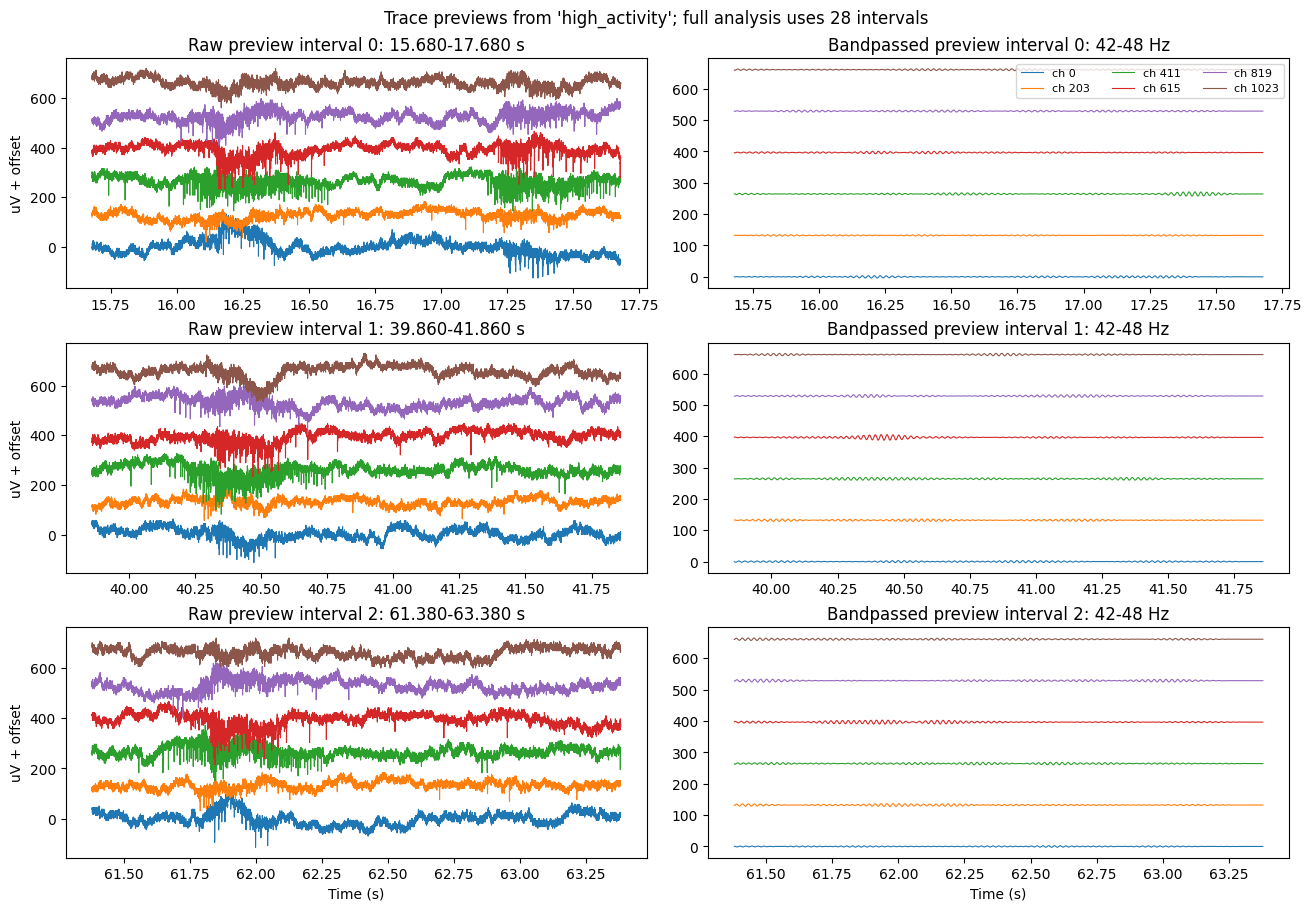

In [384]:
preview_blocks = [load_lfp_interval(interval) for interval in lfp_preview_intervals]
fig, axes = plt.subplots(len(preview_blocks), 2, figsize=(13, 3.0 * len(preview_blocks)), squeeze=False, constrained_layout=True)
for panel_idx, (raw_i, band_i, t_raw_i, t_ds_i, coords_i, fs_i, mapping_i) in enumerate(preview_blocks):
    raw_uv = raw_i[:, channels] * 1e6
    band_uv = band_i[:, channels] * 1e6
    raw_uv = raw_uv - np.nanmedian(raw_uv, axis=0, keepdims=True)
    band_uv = band_uv - np.nanmedian(band_uv, axis=0, keepdims=True)
    robust_span = np.nanpercentile(np.concatenate([np.abs(raw_uv).ravel(), np.abs(band_uv).ravel()]), 95)
    offset_step = max(5.0, 3.0 * robust_span)
    offsets = np.arange(len(channels)) * offset_step
    for row, ch in enumerate(channels):
        label = f"ch {int(mapping_i['channel'][ch])}"
        axes[panel_idx, 0].plot(t_raw_i, raw_uv[:, row] + offsets[row], lw=0.8, label=label if panel_idx == 0 else None)
        axes[panel_idx, 1].plot(t_ds_i, band_uv[:, row] + offsets[row], lw=0.8, label=label if panel_idx == 0 else None)
    axes[panel_idx, 0].set_ylabel("uV + offset")
    axes[panel_idx, 0].set_title(f"Raw preview interval {panel_idx}: {t_raw_i[0]:.3f}-{t_raw_i[-1]:.3f} s")
    axes[panel_idx, 1].set_title(f"Bandpassed preview interval {panel_idx}: {BAND_LOW:g}-{BAND_HIGH:g} Hz")
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)")
axes[0, 1].legend(loc="upper right", ncols=3, fontsize=8)
fig.suptitle(f"Trace previews from {WAVE_INTERVAL_MODE!r}; full analysis uses {len(lfp_analysis_intervals)} intervals")


## Morlet Spectrogram Preview


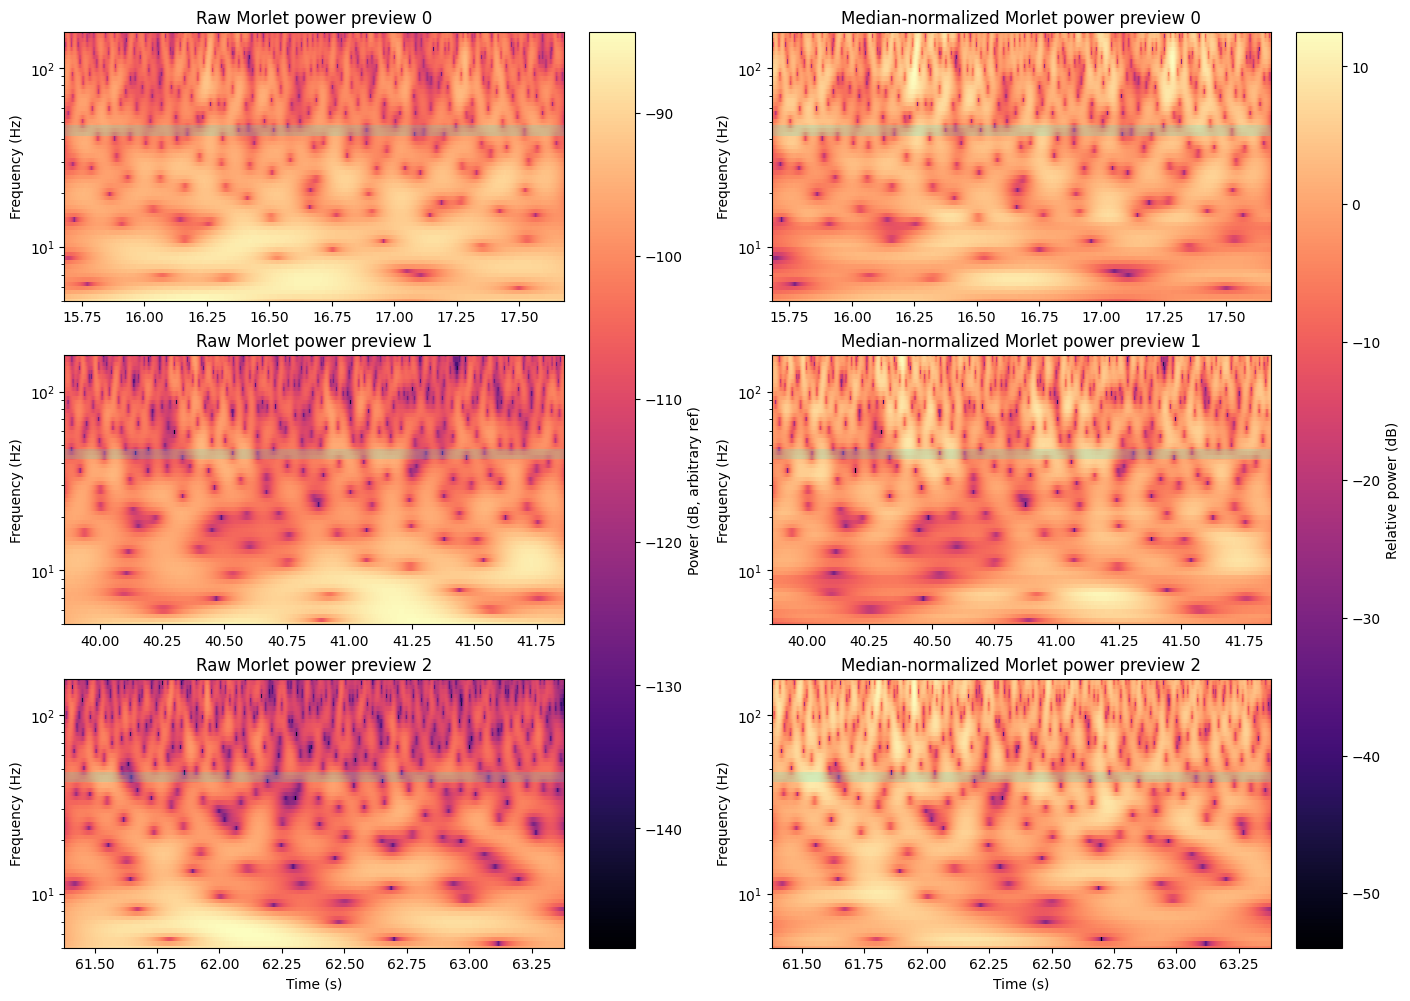

In [385]:
def morlet_power(trace, fs, freqs, n_cycles=7.0):
    power = np.empty((len(freqs), trace.size), dtype=float)
    for idx, freq in enumerate(freqs):
        sigma_t = n_cycles / (2.0 * np.pi * freq)
        half_width = int(np.ceil(4.0 * sigma_t * fs))
        tau = np.arange(-half_width, half_width + 1) / fs
        wavelet = np.exp(2j * np.pi * freq * tau) * np.exp(-0.5 * (tau / sigma_t) ** 2)
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))
        coef_full = np.convolve(trace, wavelet.conj()[::-1], mode="full")
        crop_start = max(0, (coef_full.size - trace.size) // 2)
        coef = coef_full[crop_start:crop_start + trace.size]
        power[idx] = np.abs(coef) ** 2
    return power

freqs = np.geomspace(5.0, min(160.0, FS_DS / 2.5), 64)
fig, axes = plt.subplots(len(preview_blocks), 2, figsize=(14, 3.3 * len(preview_blocks)), squeeze=False, constrained_layout=True)
for panel_idx, (raw_i, band_i, t_raw_i, t_ds_i, coords_i, fs_i, mapping_i) in enumerate(preview_blocks):
    spectro_ds = bandpass_downsample(raw_i, fs_i, SPECTRO_LOW, SPECTRO_HIGH, FS_DS, max_channels_per_block=128)
    spectro_trace = np.nanmedian(spectro_ds[:, channels], axis=1)
    spectro_trace = spectro_trace - np.nanmedian(spectro_trace)
    power = morlet_power(spectro_trace, FS_DS, freqs)
    power_raw_db = 10.0 * np.log10(power + 1e-24)
    power_db = 10.0 * np.log10(power / np.nanmedian(power, axis=1, keepdims=True) + 1e-12)
    mesh0 = axes[panel_idx, 0].pcolormesh(t_ds_i, freqs, power_raw_db, shading="auto", cmap="magma")
    mesh1 = axes[panel_idx, 1].pcolormesh(t_ds_i, freqs, power_db, shading="auto", cmap="magma")
    for ax in axes[panel_idx, :]:
        ax.axhspan(BAND_LOW, BAND_HIGH, color="cyan", alpha=0.16, lw=0)
        ax.set_yscale("log")
        ax.set_ylim(freqs.min(), freqs.max())
        ax.set_ylabel("Frequency (Hz)")
    axes[panel_idx, 0].set_title(f"Raw Morlet power preview {panel_idx}")
    axes[panel_idx, 1].set_title(f"Median-normalized Morlet power preview {panel_idx}")
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)")
fig.colorbar(mesh0, ax=axes[:, 0], label="Power (dB, arbitrary ref)")
fig.colorbar(mesh1, ax=axes[:, 1], label="Relative power (dB)")


## PSD Log-Log Spectrum Across All Selected Intervals


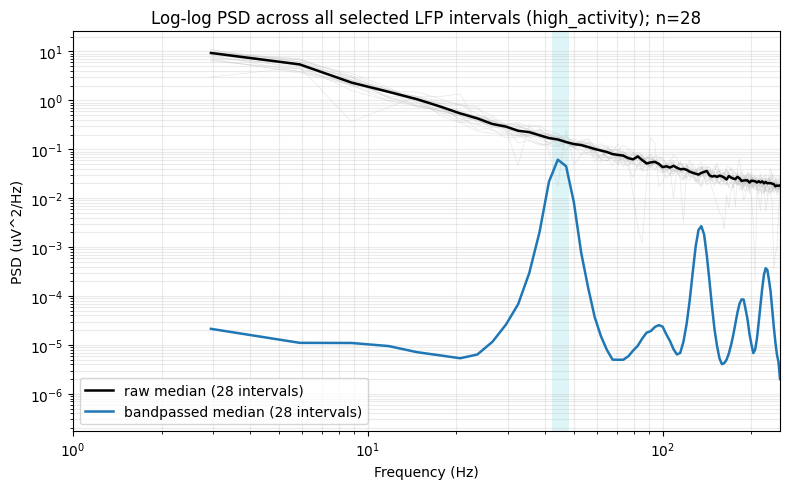

In [386]:
interval_durations = np.array([b - a for a, b in lfp_analysis_intervals], dtype=float)
min_interval_s = float(np.nanmin(interval_durations))
common_raw_nperseg = max(4, min(int(info["fs_raw"]), int(np.floor(min_interval_s * info["fs_raw"]))))
common_band_nperseg = max(4, min(int(FS_DS), int(np.floor(min_interval_s * FS_DS))))

psd_raw_chunks = []
psd_band_chunks = []
freq_raw_ref = None
freq_band_ref = None
for interval in lfp_analysis_intervals:
    raw_i, band_i, t_raw_i, t_ds_i, coords_i, fs_i, mapping_i = load_lfp_interval(interval)
    psd_trace_raw = np.nanmedian(raw_i[:, channels], axis=1)
    psd_trace_raw = psd_trace_raw - np.nanmedian(psd_trace_raw)
    psd_trace_band = np.nanmedian(band_i[:, channels], axis=1)
    psd_trace_band = psd_trace_band - np.nanmedian(psd_trace_band)
    if len(psd_trace_raw) >= common_raw_nperseg:
        freq_raw_i, psd_raw_i = welch(psd_trace_raw, fs=fs_i, nperseg=common_raw_nperseg)
        freq_raw_ref = freq_raw_i if freq_raw_ref is None else freq_raw_ref
        psd_raw_chunks.append(psd_raw_i)
    if len(psd_trace_band) >= common_band_nperseg:
        freq_band_i, psd_band_i = welch(psd_trace_band, fs=FS_DS, nperseg=common_band_nperseg)
        freq_band_ref = freq_band_i if freq_band_ref is None else freq_band_ref
        psd_band_chunks.append(psd_band_i)

psd_raw_stack = np.asarray(psd_raw_chunks)
psd_band_stack = np.asarray(psd_band_chunks)
fig, ax = plt.subplots(figsize=(8, 5))
if psd_raw_stack.size:
    for psd_i in psd_raw_stack[:20]:
        ax.loglog(freq_raw_ref[1:], psd_i[1:] * 1e12, color="0.75", lw=0.5, alpha=0.35)
    ax.loglog(freq_raw_ref[1:], np.nanmedian(psd_raw_stack, axis=0)[1:] * 1e12, color="black", lw=1.8, label=f"raw median ({len(psd_raw_stack)} intervals)")
if psd_band_stack.size:
    ax.loglog(freq_band_ref[1:], np.nanmedian(psd_band_stack, axis=0)[1:] * 1e12, color="tab:blue", lw=1.8, label=f"bandpassed median ({len(psd_band_stack)} intervals)")
ax.axvspan(BAND_LOW, BAND_HIGH, color="tab:cyan", alpha=0.14, lw=0)
ax.set_xlim(1, min(fs_raw, FS_DS) / 2)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (uV^2/Hz)")
ax.set_title(f"Log-log PSD across all selected LFP intervals ({WAVE_INTERVAL_MODE}); n={len(lfp_analysis_intervals)}")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.tight_layout()


## Single-Window Phase Fit Preview


{'fit': {'kx': 5.420487457180399,
  'ky': -11.337194461062118,
  'R_fit': 0.08555566828134947,
  'n_good': 1020},
 'radial_fit': {'radial_x0_mm': 3.252112463278095,
  'radial_y0_mm': 0.38287641019716034,
  'radial_k': 6.291436651612127,
  'radial_sign': -1,
  'R_radial': 0.07489796807113432,
  'radial_n_good': 1020},
 'omega': 282.12021926072737,
 'f_peak': nan}

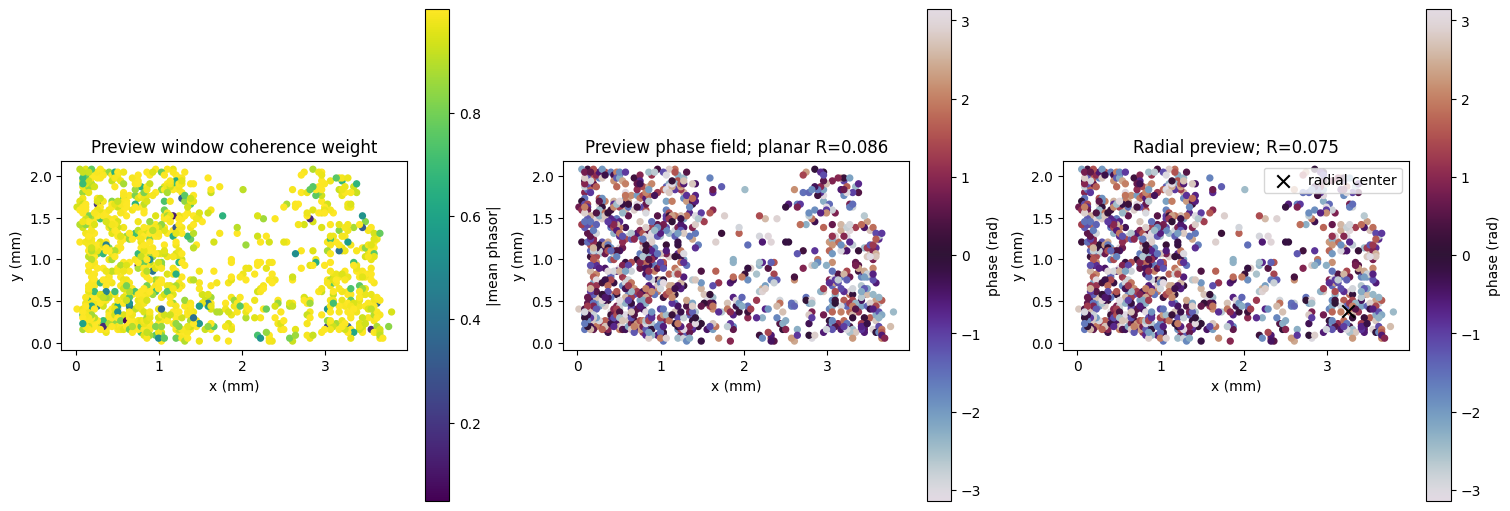

In [387]:
u, amp = extract_phasors(band_ds)
win_n = int(round(WIN_MS * FS_DS / 1000.0))
w0 = min(len(u) // 2, max(0, len(u) - win_n))
u_win = u[w0:w0 + win_n]
amp_win = amp[w0:w0 + win_n]
amp_weights = np.nanmean(amp_win, axis=0)
omega, f_peak = estimate_omega(u_win, band_ds[w0:w0 + win_n], FS_DS, method="channel_phase_derivative", band_low=BAND_LOW, band_high=BAND_HIGH, weights=amp_weights)
ubar = demodulated_window_phasor(u_win, amp_win, FS_DS, omega)
weights = np.abs(ubar)

k_grid = make_k_grid(LAMBDA_MIN, LAMBDA_MAX, n_grid=41)
fit = fit_k_phasor_plane(ubar, weights, coords_mm, k_grid, refine=True)
radial_grid_preview = make_radial_grid(
    coords_mm,
    center_grid_n=RADIAL_CENTER_GRID_N,
    center_margin_mm=RADIAL_CENTER_MARGIN_MM,
    lambda_min_mm=LAMBDA_MIN,
    lambda_max_mm=LAMBDA_MAX,
    k_grid_n=41,
)
radial_fit = fit_k_radial_phasor(ubar, weights, coords_mm, radial_grid_preview, refine=True) if FIT_RADIAL else None
phase = np.angle(ubar)

fig, axes = plt.subplots(1, 3 if FIT_RADIAL else 2, figsize=(15 if FIT_RADIAL else 12, 5), constrained_layout=True)
axes = np.atleast_1d(axes)
sc0 = axes[0].scatter(coords_mm[:, 0], coords_mm[:, 1], c=weights, s=18, cmap="viridis")
axes[0].set_title("Preview window coherence weight")
fig.colorbar(sc0, ax=axes[0], label="|mean phasor|")
sc1 = axes[1].scatter(coords_mm[:, 0], coords_mm[:, 1], c=phase, s=18, cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[1].set_title(f"Preview phase field; planar R={fit['R_fit']:.3f}")
fig.colorbar(sc1, ax=axes[1], label="phase (rad)")
if FIT_RADIAL:
    sc2 = axes[2].scatter(coords_mm[:, 0], coords_mm[:, 1], c=phase, s=18, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[2].scatter([radial_fit["radial_x0_mm"]], [radial_fit["radial_y0_mm"]], marker="x", s=80, c="black", label="radial center")
    axes[2].set_title(f"Radial preview; R={radial_fit['R_radial']:.3f}")
    axes[2].legend(loc="upper right")
    fig.colorbar(sc2, ax=axes[2], label="phase (rad)")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
{"fit": fit, "radial_fit": radial_fit, "omega": omega, "f_peak": f_peak}


## Single-Window Fit Preview Diagnostics


Text(0, 0.5, '|ubar| after')

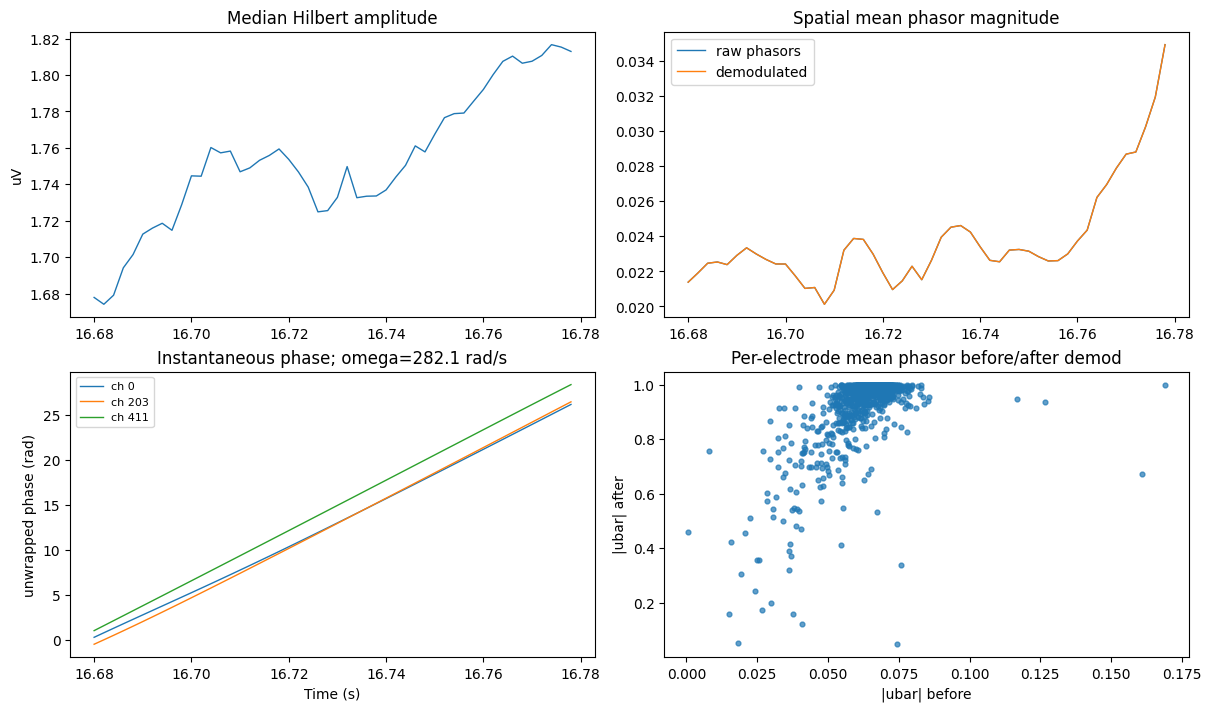

In [388]:
window_t = t_ds[w0:w0 + win_n]
naive_ubar = np.divide((amp_win * u_win).sum(axis=0), amp_win.sum(axis=0), out=np.zeros(u.shape[1], dtype=np.complex64), where=amp_win.sum(axis=0) > 1e-12)
demod_t = (np.arange(win_n) - 0.5 * (win_n - 1)) / FS_DS
u_win_demod = u_win * np.exp(-1j * omega * demod_t)[:, None]
mean_before = np.abs(np.nanmean(u_win, axis=1))
mean_after = np.abs(np.nanmean(u_win_demod, axis=1))

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
axes[0, 0].plot(window_t, np.nanmedian(amp_win, axis=1) * 1e6, lw=1.0)
axes[0, 0].set_title("Median Hilbert amplitude")
axes[0, 0].set_ylabel("uV")
axes[0, 1].plot(window_t, mean_before, label="raw phasors", lw=1.0)
axes[0, 1].plot(window_t, mean_after, label="demodulated", lw=1.0)
axes[0, 1].set_title("Spatial mean phasor magnitude")
axes[0, 1].legend()
for row, ch in enumerate(channels[:3]):
    axes[1, 0].plot(window_t, np.unwrap(np.angle(u_win[:, ch])), lw=1.0, label=f"ch {int(mapping['channel'][ch])}")
axes[1, 0].set_title(f"Instantaneous phase; omega={omega:.1f} rad/s")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("unwrapped phase (rad)")
axes[1, 0].legend(fontsize=8)
axes[1, 1].scatter(np.abs(naive_ubar), weights, s=12, alpha=0.7)
axes[1, 1].set_title("Per-electrode mean phasor before/after demod")
axes[1, 1].set_xlabel("|ubar| before")
axes[1, 1].set_ylabel("|ubar| after")


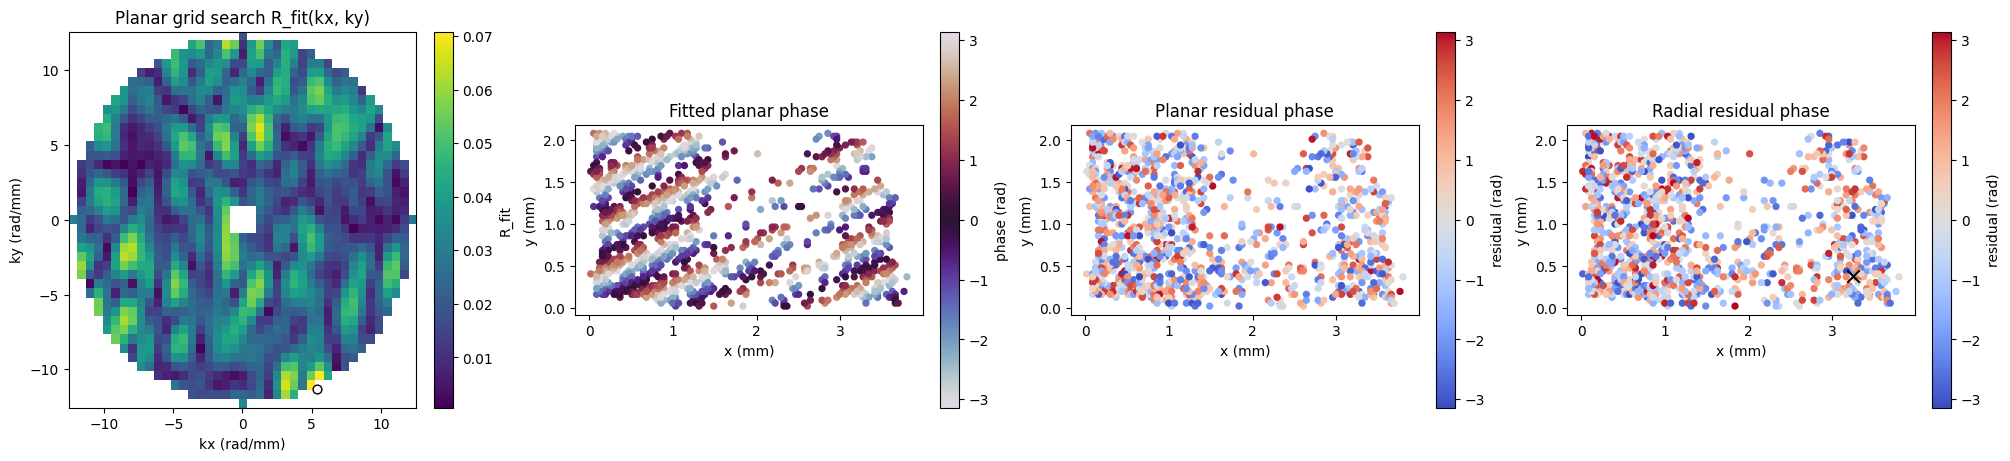

In [389]:
kx_axis = np.asarray(k_grid["kx"])
ky_axis = np.asarray(k_grid["ky"])
score = np.full((len(ky_axis), len(kx_axis)), np.nan)
weighted_ubar = weights * ubar
weight_sum = np.sum(weights)
for ix, kx in enumerate(kx_axis):
    phase_x = kx * coords_mm[:, 0]
    for iy, ky in enumerate(ky_axis):
        k_norm = np.hypot(kx, ky)
        if k_grid["k_min"] <= k_norm <= k_grid["k_max"] and weight_sum > 0:
            score[iy, ix] = np.abs(np.sum(weighted_ubar * np.exp(-1j * (phase_x + ky * coords_mm[:, 1])))) / weight_sum

fit_k = np.array([fit["kx"], fit["ky"]])
fit_phase = coords_mm @ fit_k
phi0 = np.angle(np.sum(weights * ubar * np.exp(-1j * fit_phase)))
residual = np.angle(ubar * np.exp(-1j * (fit_phase + phi0)))

if FIT_RADIAL and radial_fit is not None:
    radial_dist = np.linalg.norm(coords_mm - np.array([radial_fit["radial_x0_mm"], radial_fit["radial_y0_mm"]])[None, :], axis=1)
    radial_phase = radial_fit["radial_sign"] * radial_fit["radial_k"] * radial_dist
    radial_phi0 = np.angle(np.sum(weights * ubar * np.exp(-1j * radial_phase)))
    radial_residual = np.angle(ubar * np.exp(-1j * (radial_phase + radial_phi0)))
    ncols = 4
else:
    radial_phase = None
    radial_residual = None
    ncols = 3

fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5), constrained_layout=True)
im = axes[0].imshow(score, origin="lower", extent=[kx_axis.min(), kx_axis.max(), ky_axis.min(), ky_axis.max()], aspect="auto", cmap="viridis")
axes[0].scatter([fit["kx"]], [fit["ky"]], c="white", s=40, edgecolor="black")
axes[0].set_title("Planar grid search R_fit(kx, ky)")
axes[0].set_xlabel("kx (rad/mm)")
axes[0].set_ylabel("ky (rad/mm)")
fig.colorbar(im, ax=axes[0], label="R_fit")
sc1 = axes[1].scatter(coords_mm[:, 0], coords_mm[:, 1], c=np.angle(np.exp(1j * fit_phase)), s=18, cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[1].set_title("Fitted planar phase")
fig.colorbar(sc1, ax=axes[1], label="phase (rad)")
sc2 = axes[2].scatter(coords_mm[:, 0], coords_mm[:, 1], c=residual, s=18, cmap="coolwarm", vmin=-np.pi, vmax=np.pi)
axes[2].set_title("Planar residual phase")
fig.colorbar(sc2, ax=axes[2], label="residual (rad)")
if ncols == 4:
    sc3 = axes[3].scatter(coords_mm[:, 0], coords_mm[:, 1], c=radial_residual, s=18, cmap="coolwarm", vmin=-np.pi, vmax=np.pi)
    axes[3].scatter([radial_fit["radial_x0_mm"]], [radial_fit["radial_y0_mm"]], marker="x", s=80, c="black")
    axes[3].set_title("Radial residual phase")
    fig.colorbar(sc3, ax=axes[3], label="residual (rad)")
for ax in axes[1:]:
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")


## LFP Wave Run Across Selected Intervals


In [390]:
# Keep this short for interactive work. Increase RUN_STOP_S or set it to None for a full recording run.
WAVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

recording_stop_s_for_cache = info["raw_shape"][1] / float(info["fs_raw"])
if selected_wave_intervals is None:
    expected_interval_list = [(float(process_start_s), recording_stop_s_for_cache if process_stop_s is None else float(process_stop_s))]
else:
    expected_interval_list = [(float(a), float(b)) for a, b in selected_wave_intervals]
    if process_stop_s is not None:
        expected_interval_list = [(max(float(process_start_s), a), min(float(process_stop_s), b)) for a, b in expected_interval_list]
    else:
        expected_interval_list = [(max(float(process_start_s), a), b) for a, b in expected_interval_list]
    expected_interval_list = [(max(0.0, a), min(recording_stop_s_for_cache, b)) for a, b in expected_interval_list if b > a]

expected_wave_config = {
    "file": str(FILE),
    "dataset": DATASET,
    "fs_raw": float(info["fs_raw"]),
    "band_low": BAND_LOW,
    "band_high": BAND_HIGH,
    "fs_ds": FS_DS,
    "chunk_s": CHUNK_S,
    "overlap_s": OVERLAP_S,
    "win_ms": WIN_MS,
    "hop_ms": HOP_MS,
    "lambda_min_mm": LAMBDA_MIN,
    "lambda_max_mm": LAMBDA_MAX,
    "fit_radial": FIT_RADIAL,
    "radial_center_grid_n": RADIAL_CENTER_GRID_N,
    "radial_center_margin_mm": RADIAL_CENTER_MARGIN_MM,
    "radial_delta_r_min": RADIAL_DELTA_R_MIN,
    "start_s": process_start_s,
    "stop_s": process_stop_s,
    "intervals": expected_interval_list,
}
required_wave_columns = {
    "t_center_s", "R_fit", "phase_speed_mm_per_s", "valid", "interval_idx",
    "R_radial", "radial_phase_speed_mm_per_s", "wave_model_class", "radial_valid",
}


def _json_normalize(value):
    if isinstance(value, tuple):
        return [_json_normalize(v) for v in value]
    if isinstance(value, list):
        return [_json_normalize(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def wave_cache_matches(path, expected_config, required_columns):
    if not Path(path).exists():
        return False, "missing"
    try:
        with h5py.File(path, "r") as h5:
            if "phase_waves" not in h5:
                return False, "missing /phase_waves"
            g = h5["phase_waves"]
            missing_columns = sorted(set(required_columns) - set(g.keys()))
            if missing_columns:
                return False, f"missing columns: {missing_columns}"
            if g["t_center_s"].shape[0] == 0:
                return False, "no result rows"
            config = json.loads(g.attrs.get("config", "{}"))
    except Exception as exc:
        return False, f"unreadable cache: {exc}"

    comparable_keys = [
        "file", "dataset", "band_low", "band_high", "fs_ds", "chunk_s", "overlap_s",
        "win_ms", "hop_ms", "lambda_min_mm", "lambda_max_mm", "fit_radial",
        "radial_center_grid_n", "radial_center_margin_mm", "radial_delta_r_min",
        "start_s", "stop_s", "intervals",
    ]
    for key in comparable_keys:
        expected = _json_normalize(expected_config.get(key))
        observed = _json_normalize(config.get(key))
        if expected != observed:
            return False, f"config mismatch for {key}: expected {expected!r}, found {observed!r}"
    return True, "compatible"


cache_ok, cache_reason = wave_cache_matches(OUT_PATH, expected_wave_config, required_wave_columns)
if cache_ok and not WAVE_FORCE_RECOMPUTE:
    print(f"Using cached LFP wave results: {OUT_PATH}")
else:
    if WAVE_FORCE_RECOMPUTE:
        print(f"Recomputing LFP wave results because WAVE_FORCE_RECOMPUTE=True: {OUT_PATH}")
    else:
        print(f"No compatible cache at {OUT_PATH} ({cache_reason}); running LFP wave analysis.")
    process_file(
        FILE,
        DATASET,
        OUT_PATH,
        fs_raw=0.0,
        band_low=BAND_LOW,
        band_high=BAND_HIGH,
        fs_ds=FS_DS,
        chunk_s=CHUNK_S,
        overlap_s=OVERLAP_S,
        win_ms=WIN_MS,
        hop_ms=HOP_MS,
        lambda_min=LAMBDA_MIN,
        lambda_max=LAMBDA_MAX,
        start_s=process_start_s,
        stop_s=process_stop_s,
        intervals=selected_wave_intervals,
        max_channels_per_block=256,
        fit_radial=FIT_RADIAL,
        radial_center_grid_n=RADIAL_CENTER_GRID_N,
        radial_center_margin_mm=RADIAL_CENTER_MARGIN_MM,
        radial_delta_r_min=RADIAL_DELTA_R_MIN,
    )
    print(f"Wrote {OUT_PATH} using interval mode {WAVE_INTERVAL_MODE!r}; intervals={'all' if selected_wave_intervals is None else len(selected_wave_intervals)}")
OUT_PATH


No compatible cache at /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/phase_waves_stim_removal_null_lfp_well0_DIV12_data0000_high_activity_42-48Hz_fs500_win100_hop50_lambda0.5-5_radial1.h5 (missing); running LFP wave analysis.
Wrote /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/phase_waves_stim_removal_null_lfp_well0_DIV12_data0000_high_activity_42-48Hz_fs500_win100_hop50_lambda0.5-5_radial1.h5 using interval mode 'high_activity'; intervals=28


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/phase_waves_stim_removal_null_lfp_well0_DIV12_data0000_high_activity_42-48Hz_fs500_win100_hop50_lambda0.5-5_radial1.h5')

## Result Diagnostics


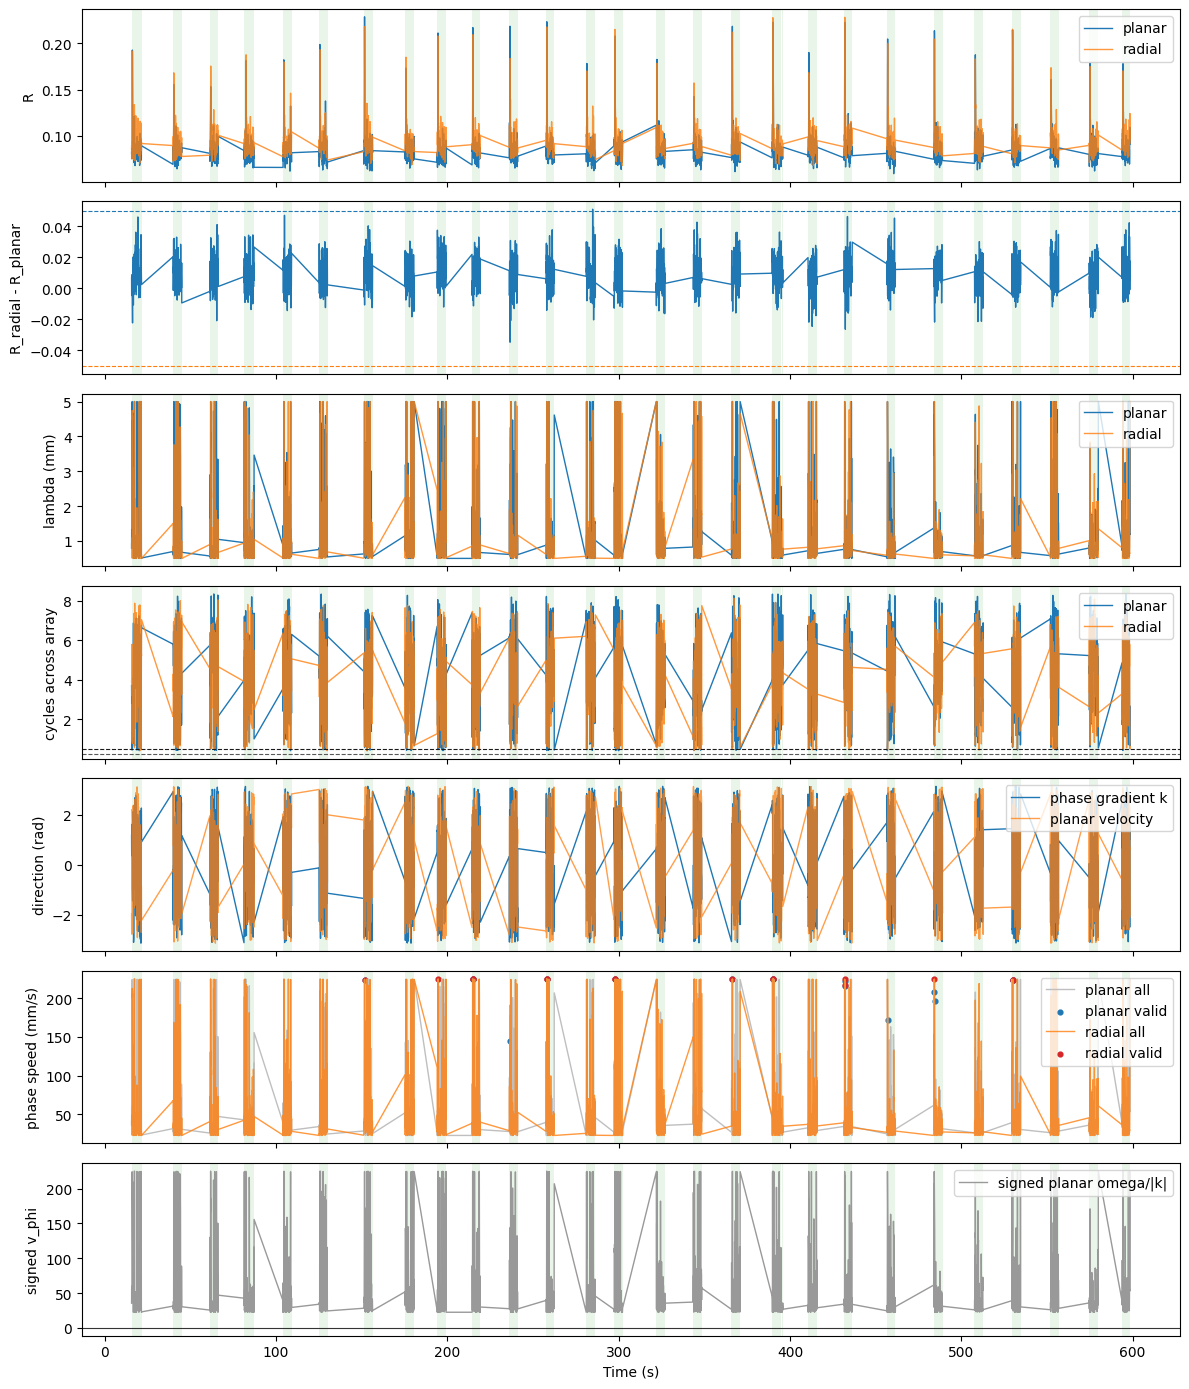

In [391]:
with h5py.File(OUT_PATH, "r") as h5:
    g = h5["phase_waves"]
    result = {name: g[name][:] for name in g.keys()}
    spatial_class_mapping = json.loads(g.attrs.get("spatial_class_mapping", '{"invalid": 0, "near_sync": 1, "weak_gradient": 2, "resolvable_wave": 3}'))
    wave_model_class_mapping = json.loads(g.attrs.get("wave_model_class_mapping", '{"invalid": 0, "near_sync": 1, "planar_like": 2, "radial_like": 3, "ambiguous": 4}'))

spatial_class_labels = {int(v): k for k, v in spatial_class_mapping.items()}
wave_model_class_labels = {int(v): k for k, v in wave_model_class_mapping.items()}
t = result["t_center_s"]
direction = result.get("direction_rad", np.arctan2(result["ky"], result["kx"]))
spatial_class = result.get("spatial_class", np.zeros_like(t, dtype=int)).astype(int)
spatial_class_name = np.array([spatial_class_labels.get(int(v), "invalid") for v in spatial_class])
propagation_valid = result.get("propagation_valid", np.zeros_like(t, dtype=bool)).astype(bool)

# Backward-compatible velocity and radial fields for older result files.
k_norm = result["k_norm"]
omega = result["omega"]
if "phase_speed_mm_per_s" not in result:
    result["phase_speed_mm_per_s"] = np.divide(np.abs(omega), k_norm, out=np.full_like(k_norm, np.nan), where=np.isfinite(k_norm) & (k_norm > 0))
if "phase_speed_peak_mm_per_s" not in result:
    f_peak = result.get("f_peak", np.full_like(k_norm, np.nan))
    result["phase_speed_peak_mm_per_s"] = np.divide(2.0 * np.pi * f_peak, k_norm, out=np.full_like(k_norm, np.nan), where=np.isfinite(k_norm) & (k_norm > 0) & np.isfinite(f_peak))
if "velocity_x_mm_per_s" not in result or "velocity_y_mm_per_s" not in result:
    denom = k_norm * k_norm
    result["velocity_x_mm_per_s"] = np.divide(-omega * result["kx"], denom, out=np.full_like(k_norm, np.nan), where=np.isfinite(denom) & (denom > 0))
    result["velocity_y_mm_per_s"] = np.divide(-omega * result["ky"], denom, out=np.full_like(k_norm, np.nan), where=np.isfinite(denom) & (denom > 0))
if "velocity_direction_rad" not in result:
    result["velocity_direction_rad"] = np.arctan2(result["velocity_y_mm_per_s"], result["velocity_x_mm_per_s"])
for name in ("radial_x0_mm", "radial_y0_mm", "radial_k", "radial_lambda_mm", "radial_aperture_mm", "radial_phase_span_rad", "radial_cycles_across_array", "R_radial", "delta_R_radial_minus_planar", "radial_phase_speed_mm_per_s"):
    result.setdefault(name, np.full_like(t, np.nan, dtype=float))
for name in ("radial_sign", "wave_model_class", "radial_valid"):
    result.setdefault(name, np.zeros_like(t, dtype=int))
radial_valid = result["radial_valid"].astype(bool)
wave_model_class = result["wave_model_class"].astype(int)
wave_model_class_name = np.array([wave_model_class_labels.get(int(v), "invalid") for v in wave_model_class])

fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)
if selected_wave_intervals is not None:
    for ax in axes:
        for a, b in selected_wave_intervals:
            ax.axvspan(a, b, color="tab:green" if WAVE_INTERVAL_MODE == "high_activity" else "tab:red", alpha=0.10, lw=0)
axes[0].plot(t, result["R_fit"], lw=1.0, label="planar")
axes[0].plot(t, result["R_radial"], lw=1.0, alpha=0.8, label="radial")
axes[0].set_ylabel("R")
axes[0].legend(loc="upper right")
axes[1].plot(t, result["delta_R_radial_minus_planar"], lw=1.0)
axes[1].axhline(RADIAL_DELTA_R_MIN, color="tab:blue", ls="--", lw=0.8)
axes[1].axhline(-RADIAL_DELTA_R_MIN, color="tab:orange", ls="--", lw=0.8)
axes[1].set_ylabel("R_radial - R_planar")
axes[2].plot(t, result["lambda_mm"], lw=1.0, label="planar")
axes[2].plot(t, result["radial_lambda_mm"], lw=1.0, alpha=0.8, label="radial")
axes[2].set_ylabel("lambda (mm)")
axes[2].legend(loc="upper right")
axes[3].plot(t, result.get("cycles_across_array", np.full_like(t, np.nan)), lw=1.0, label="planar")
axes[3].plot(t, result["radial_cycles_across_array"], lw=1.0, alpha=0.8, label="radial")
axes[3].axhline(0.25, color="0.35", ls="--", lw=0.8)
axes[3].axhline(0.5, color="0.10", ls="--", lw=0.8)
axes[3].set_ylabel("cycles across array")
axes[3].legend(loc="upper right")
axes[4].plot(t, direction, lw=1.0, label="phase gradient k")
axes[4].plot(t, result["velocity_direction_rad"], lw=1.0, alpha=0.75, label="planar velocity")
axes[4].set_ylabel("direction (rad)")
axes[4].legend(loc="upper right")
axes[5].plot(t, result["phase_speed_mm_per_s"], color="0.75", lw=1.0, label="planar all")
axes[5].scatter(t[propagation_valid], result["phase_speed_mm_per_s"][propagation_valid], s=12, color="tab:blue", label="planar valid")
axes[5].plot(t, result["radial_phase_speed_mm_per_s"], color="tab:orange", lw=1.0, alpha=0.8, label="radial all")
axes[5].scatter(t[radial_valid], result["radial_phase_speed_mm_per_s"][radial_valid], s=12, color="tab:red", label="radial valid")
axes[5].set_ylabel("phase speed (mm/s)")
axes[5].legend(loc="upper right")
axes[6].plot(t, result.get("v_phi_mm_per_s", np.full_like(t, np.nan)), color="0.6", lw=1.0, label="signed planar omega/|k|")
axes[6].axhline(0.0, color="0.2", lw=0.8)
axes[6].set_ylabel("signed v_phi")
axes[6].set_xlabel("Time (s)")
axes[6].legend(loc="upper right")
plt.tight_layout()


## Result QC Summary


,interval_idx,n_windows,t_start_s,t_stop_s,R_fit_median,R_radial_median,delta_R_median,mean_weight_median,lambda_mm_median,radial_lambda_mm_median,...,velocity_direction_rad_median,propagation_valid_fraction,radial_valid_fraction,resolvable_wave,weak_gradient,model_ambiguous,model_invalid,model_near_sync,model_planar_like,model_radial_like
0,0,117,15.68,21.48,0.083,0.094,0.008,0.932,0.815,0.771,...,-0.668,0.000,0.000,112,5,0,109,8,0,0
1,1,103,39.86,44.96,0.084,0.093,0.010,0.931,0.702,0.725,...,-0.224,0.000,0.000,98,5,0,97,6,0,0
2,2,100,61.38,66.33,0.084,0.093,0.010,0.931,0.850,0.752,...,-0.078,0.000,0.000,97,3,0,95,5,0,0
3,3,119,81.28,87.18,0.082,0.092,0.010,0.931,0.749,0.746,...,0.722,0.000,0.000,118,1,0,117,2,0,0
4,4,101,104.08,109.08,0.082,0.090,0.008,0.933,0.735,0.725,...,0.362,0.000,0.000,98,3,0,98,3,0,0
5,5,98,125.16,130.01,0.083,0.090,0.008,0.931,0.787,0.684,...,0.625,0.000,0.000,97,1,0,96,2,0,0
6,6,105,151.16,156.36,0.084,0.093,0.012,0.932,0.854,0.822,...,0.239,0.010,0.010,100,5,1,99,5,0,0
7,7,108,175.28,180.63,0.081,0.090,0.007,0.932,0.776,0.789,...,0.112,0.000,0.000,104,4,0,103,5,0,0
8,8,106,194.04,199.29,0.079,0.094,0.012,0.932,0.732,0.716,...,-0.523,0.000,0.009,99,7,0,99,6,0,1
9,9,98,214.40,219.25,0.082,0.093,0.010,0.932,0.789,0.764,...,0.341,0.020,0.020,94,4,2,90,6,0,0


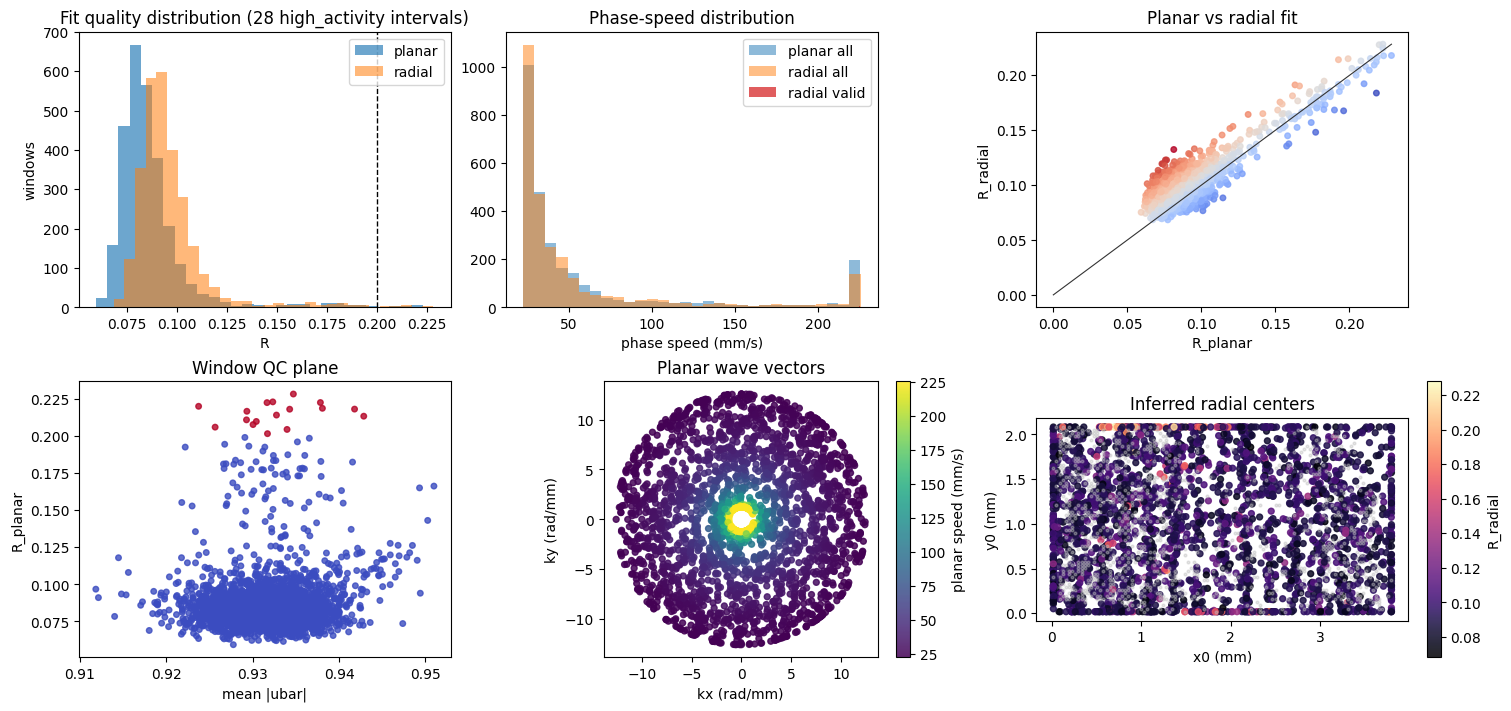

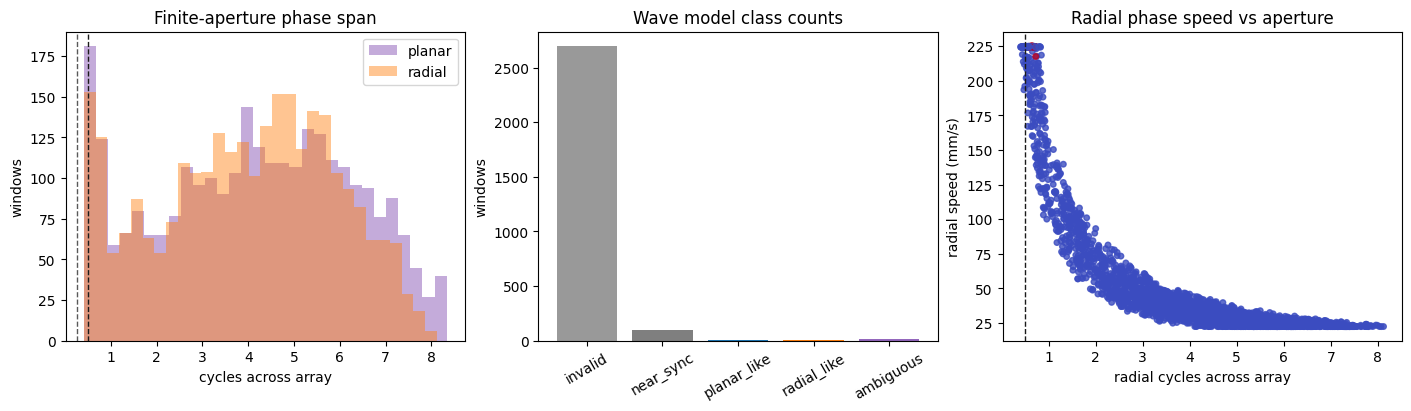

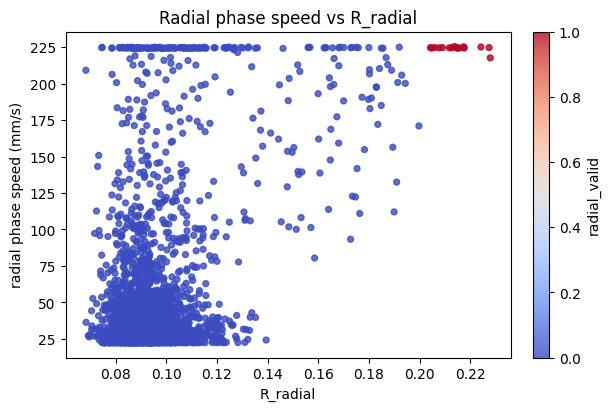

In [395]:
valid = result.get("valid", np.zeros_like(t, dtype=bool)).astype(bool)
interval_note = "continuous" if selected_wave_intervals is None else f"{len(selected_wave_intervals)} {WAVE_INTERVAL_MODE} intervals"
result_df = pd.DataFrame({name: values for name, values in result.items()})
if "spatial_class" in result_df:
    result_df["spatial_class_name"] = [spatial_class_labels.get(int(v), "invalid") for v in result_df["spatial_class"]]
if "wave_model_class" in result_df:
    result_df["wave_model_class_name"] = [wave_model_class_labels.get(int(v), "invalid") for v in result_df["wave_model_class"]]
if "propagation_valid" in result_df:
    result_df["propagation_valid"] = result_df["propagation_valid"].astype(bool)
if "radial_valid" in result_df:
    result_df["radial_valid"] = result_df["radial_valid"].astype(bool)

if "interval_idx" in result_df and not result_df.empty:
    result_interval_summary = (
        result_df.groupby("interval_idx", as_index=False)
        .agg(
            n_windows=("t_center_s", "size"),
            t_start_s=("t_center_s", "min"),
            t_stop_s=("t_center_s", "max"),
            R_fit_median=("R_fit", "median"),
            R_radial_median=("R_radial", "median"),
            delta_R_median=("delta_R_radial_minus_planar", "median"),
            mean_weight_median=("mean_weight", "median"),
            lambda_mm_median=("lambda_mm", "median"),
            radial_lambda_mm_median=("radial_lambda_mm", "median"),
            cycles_across_array_median=("cycles_across_array", "median"),
            radial_cycles_across_array_median=("radial_cycles_across_array", "median"),
            omega_median=("omega", "median"),
            phase_speed_mm_per_s_median=("phase_speed_mm_per_s", "median"),
            radial_phase_speed_mm_per_s_median=("radial_phase_speed_mm_per_s", "median"),
            velocity_direction_rad_median=("velocity_direction_rad", "median"),
            propagation_valid_fraction=("propagation_valid", "mean"),
            radial_valid_fraction=("radial_valid", "mean"),
        )
    )
    spatial_counts = result_df.pivot_table(index="interval_idx", columns="spatial_class_name", values="t_center_s", aggfunc="size", fill_value=0)
    model_counts = result_df.pivot_table(index="interval_idx", columns="wave_model_class_name", values="t_center_s", aggfunc="size", fill_value=0)
    result_interval_summary = result_interval_summary.merge(spatial_counts.reset_index(), on="interval_idx", how="left")
    result_interval_summary = result_interval_summary.merge(model_counts.add_prefix("model_").reset_index(), on="interval_idx", how="left")
    display(result_interval_summary.head(20).round(3))
else:
    result_interval_summary = pd.DataFrame()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
axes[0, 0].hist(result["R_fit"][np.isfinite(result["R_fit"])], bins=30, color="tab:blue", alpha=0.65, label="planar")
axes[0, 0].hist(result["R_radial"][np.isfinite(result["R_radial"])], bins=30, color="tab:orange", alpha=0.55, label="radial")
axes[0, 0].axvline(0.2, color="black", ls="--", lw=1.0)
axes[0, 0].set_title(f"Fit quality distribution ({interval_note})")
axes[0, 0].set_xlabel("R")
axes[0, 0].set_ylabel("windows")
axes[0, 0].legend(loc="upper right")
axes[0, 1].hist(result["phase_speed_mm_per_s"][np.isfinite(result["phase_speed_mm_per_s"])], bins=30, color="tab:blue", alpha=0.50, label="planar all")
axes[0, 1].hist(result["radial_phase_speed_mm_per_s"][np.isfinite(result["radial_phase_speed_mm_per_s"])], bins=30, color="tab:orange", alpha=0.50, label="radial all")
if np.any(radial_valid):
    axes[0, 1].hist(result["radial_phase_speed_mm_per_s"][radial_valid & np.isfinite(result["radial_phase_speed_mm_per_s"])], bins=30, color="tab:red", alpha=0.75, label="radial valid")
axes[0, 1].set_title("Phase-speed distribution")
axes[0, 1].set_xlabel("phase speed (mm/s)")
axes[0, 1].legend(loc="upper right")
axes[0, 2].scatter(result["R_fit"], result["R_radial"], c=result["delta_R_radial_minus_planar"], s=16, cmap="coolwarm", alpha=0.8)
axes[0, 2].plot([0, max(result["R_fit"])], [0, max(result["R_radial"])], color="0.2", lw=0.8)
axes[0, 2].set_title("Planar vs radial fit")
axes[0, 2].set_xlabel("R_planar")
axes[0, 2].set_ylabel("R_radial")
axes[1, 0].scatter(result["mean_weight"], result["R_fit"], c=valid, s=16, cmap="coolwarm", alpha=0.8)
axes[1, 0].set_title("Window QC plane")
axes[1, 0].set_xlabel("mean |ubar|")
axes[1, 0].set_ylabel("R_planar")
sc = axes[1, 1].scatter(result["kx"], result["ky"], c=result["phase_speed_mm_per_s"], s=18, cmap="viridis", alpha=0.85)
axes[1, 1].set_title("Planar wave vectors")
axes[1, 1].set_xlabel("kx (rad/mm)")
axes[1, 1].set_ylabel("ky (rad/mm)")
axes[1, 1].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[1, 1], label="planar speed (mm/s)")
sc2 = axes[1, 2].scatter(result["radial_x0_mm"], result["radial_y0_mm"], c=result["R_radial"], s=18, cmap="magma", alpha=0.85)
axes[1, 2].scatter(coords_mm[:, 0], coords_mm[:, 1], s=4, color="0.75", alpha=0.4)
axes[1, 2].set_title("Inferred radial centers")
axes[1, 2].set_xlabel("x0 (mm)")
axes[1, 2].set_ylabel("y0 (mm)")
axes[1, 2].set_aspect("equal", adjustable="box")
fig.colorbar(sc2, ax=axes[1, 2], label="R_radial")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
cycles = result.get("cycles_across_array", np.full_like(t, np.nan))
axes[0].hist(cycles[np.isfinite(cycles)], bins=30, color="tab:purple", alpha=0.55, label="planar")
axes[0].hist(result["radial_cycles_across_array"][np.isfinite(result["radial_cycles_across_array"])], bins=30, color="tab:orange", alpha=0.45, label="radial")
axes[0].axvline(0.25, color="0.35", ls="--", lw=1.0)
axes[0].axvline(0.5, color="0.10", ls="--", lw=1.0)
axes[0].set_title("Finite-aperture phase span")
axes[0].set_xlabel("cycles across array")
axes[0].set_ylabel("windows")
axes[0].legend(loc="upper right")
model_order = ["invalid", "near_sync", "planar_like", "radial_like", "ambiguous"]
model_counts_total = pd.Series(wave_model_class_name).value_counts().reindex(model_order, fill_value=0)
axes[1].bar(model_counts_total.index, model_counts_total.values, color=["0.6", "tab:gray", "tab:blue", "tab:orange", "tab:purple"])
axes[1].set_title("Wave model class counts")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylabel("windows")
axes[2].scatter(result["radial_cycles_across_array"], result["radial_phase_speed_mm_per_s"], c=radial_valid, cmap="coolwarm", s=16, alpha=0.8)
axes[2].axvline(0.5, color="0.10", ls="--", lw=1.0)
axes[2].set_title("Radial phase speed vs aperture")
axes[2].set_xlabel("radial cycles across array")
axes[2].set_ylabel("radial speed (mm/s)")

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
r2_radial = result["R_radial"]
speed = result["radial_phase_speed_mm_per_s"]
finite = np.isfinite(r2_radial) & np.isfinite(speed)
sc = ax.scatter(r2_radial[finite], speed[finite], c=radial_valid[finite], cmap="coolwarm", s=18, alpha=0.8)
ax.set_title("Radial phase speed vs R_radial")
ax.set_xlabel("R_radial")
ax.set_ylabel("radial phase speed (mm/s)")
fig.colorbar(sc, ax=ax, label="radial_valid")



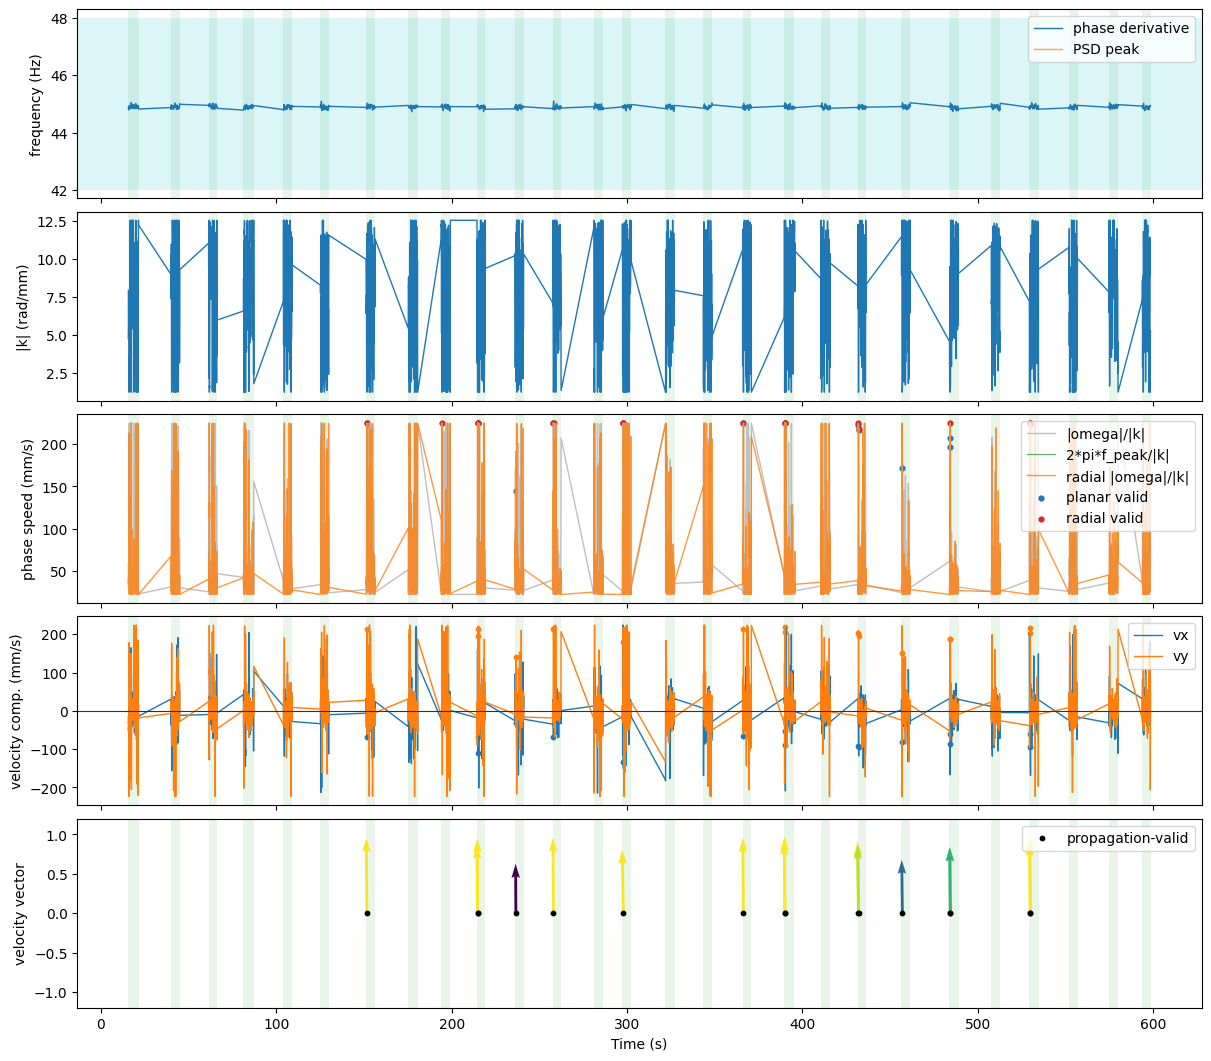

In [393]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10.5), sharex=True, constrained_layout=True)
if selected_wave_intervals is not None:
    for ax in axes:
        for a, b in selected_wave_intervals:
            ax.axvspan(a, b, color="tab:green" if WAVE_INTERVAL_MODE == "high_activity" else "tab:red", alpha=0.10, lw=0)
axes[0].plot(t, result["omega"] / (2.0 * np.pi), lw=1.0, label="phase derivative")
if "f_peak" in result:
    axes[0].plot(t, result["f_peak"], lw=1.0, alpha=0.7, label="PSD peak")
axes[0].axhspan(BAND_LOW, BAND_HIGH, color="tab:cyan", alpha=0.15, lw=0)
axes[0].set_ylabel("frequency (Hz)")
axes[0].legend(loc="upper right")
axes[1].plot(t, result["k_norm"], lw=1.0)
axes[1].set_ylabel("|k| (rad/mm)")
axes[2].plot(t, result["phase_speed_mm_per_s"], color="0.75", lw=1.0, label="|omega|/|k|")
axes[2].plot(t, result["phase_speed_peak_mm_per_s"], color="tab:green", lw=0.9, alpha=0.75, label="2*pi*f_peak/|k|")
axes[2].plot(t, result["radial_phase_speed_mm_per_s"], color="tab:orange", lw=1.0, alpha=0.8, label="radial |omega|/|k|")
axes[2].scatter(t[propagation_valid], result["phase_speed_mm_per_s"][propagation_valid], s=12, color="tab:blue", label="planar valid")
axes[2].scatter(t[radial_valid], result["radial_phase_speed_mm_per_s"][radial_valid], s=12, color="tab:red", label="radial valid")
axes[2].set_ylabel("phase speed (mm/s)")
axes[2].legend(loc="upper right")
axes[3].plot(t, result["velocity_x_mm_per_s"], color="tab:blue", lw=1.0, label="vx")
axes[3].plot(t, result["velocity_y_mm_per_s"], color="tab:orange", lw=1.0, label="vy")
axes[3].scatter(t[propagation_valid], result["velocity_x_mm_per_s"][propagation_valid], s=10, color="tab:blue")
axes[3].scatter(t[propagation_valid], result["velocity_y_mm_per_s"][propagation_valid], s=10, color="tab:orange")
axes[3].axhline(0.0, color="0.2", lw=0.8)
axes[3].set_ylabel("velocity comp. (mm/s)")
axes[3].legend(loc="upper right")
quiv_idx = propagation_valid & np.isfinite(result["velocity_x_mm_per_s"]) & np.isfinite(result["velocity_y_mm_per_s"])
if not np.any(quiv_idx):
    quiv_idx = np.isfinite(result["velocity_x_mm_per_s"]) & np.isfinite(result["velocity_y_mm_per_s"])
quiver_scale = np.nanpercentile(result["phase_speed_mm_per_s"], 95)
if not np.isfinite(quiver_scale) or quiver_scale <= 0:
    quiver_scale = 1.0
axes[4].quiver(t[quiv_idx], np.zeros(np.count_nonzero(quiv_idx)), result["velocity_x_mm_per_s"][quiv_idx], result["velocity_y_mm_per_s"][quiv_idx], result["phase_speed_mm_per_s"][quiv_idx], angles="xy", scale_units="xy", scale=quiver_scale, width=0.0025, cmap="viridis")
axes[4].scatter(t[propagation_valid], np.zeros(np.count_nonzero(propagation_valid)), s=10, color="black", label="propagation-valid")
axes[4].set_ylim(-1.2, 1.2)
axes[4].set_ylabel("velocity vector")
axes[4].set_xlabel("Time (s)")
axes[4].legend(loc="upper right")
